In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to  : {SEED}')

TensorFlow version : 2.20.0
Random seed set to  : 42


In [3]:
RESULTS_DIR = '/content/drive/MyDrive/ME1/results/'
MODEL_DIR   = '/content/drive/MyDrive/ME1/model/'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)
print('Results will be saved to:', RESULTS_DIR)
print('Models  will be saved to:', MODEL_DIR)

Results will be saved to: /content/drive/MyDrive/ME1/results/
Models  will be saved to: /content/drive/MyDrive/ME1/model/


In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('No GPU found — training will run on CPU.')

GPUs available: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
import kagglehub

# Dataset: saravanansri/fruits-disease-dataset
# Structure:
#   Dataset/
#     train/  Mango/  Formalin-mixed/
#                     Fresh/
#                     Rotten/
#     valid/  Mango/  Formalin-mixed/
#                     Fresh/
#                     Rotten/
#     test/   Mango/  Formalin-mixed/
#                     Fresh/
#                     Rotten/
# We only use Rotten and Formalin-mixed from the Mango folder.
path = kagglehub.dataset_download('saravanansri/fruits-disease-dataset')
print('Path to dataset files:', path)

Using Colab cache for faster access to the 'fruits-disease-dataset' dataset.
Path to dataset files: /kaggle/input/fruits-disease-dataset


In [6]:
# Walk top levels to confirm structure
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 4:
        n_files = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        label   = f'  ({n_files} images)' if n_files else ''
        print('  ' * depth + Path(root).name + label)
    if depth >= 4:
        dirs[:] = []

fruits-disease-dataset
  Dataset
    valid
      Orange
        Formalin-mixed  (97 images)
        Fresh  (113 images)
        Rotten  (97 images)
      Apple
        Formalin-mixed  (97 images)
        Fresh  (115 images)
        Rotten  (95 images)
      Grape
        Formalin-mixed  (92 images)
        Fresh  (116 images)
        Rotten  (95 images)
      Banana
        Formalin-mixed  (100 images)
        Fresh  (113 images)
        Rotten  (95 images)
      Mango
        Formalin-mixed  (93 images)
        Fresh  (115 images)
        Rotten  (95 images)
    test
      Orange
        Formalin-mixed  (97 images)
        Fresh  (113 images)
        Rotten  (97 images)
      Apple
        Formalin-mixed  (97 images)
        Fresh  (115 images)
        Rotten  (95 images)
      Grape
        Formalin-mixed  (92 images)
        Fresh  (116 images)
        Rotten  (95 images)
      Banana
        Formalin-mixed  (100 images)
        Fresh  (113 images)
        Rotten  (95 images)
      

In [7]:
# Locate Rotten and Formalin-mixed folders inside Mango/ for each split.
# Matches: parent == 'mango' AND grandparent in ('train', 'valid', 'test')

TARGET_SPLITS  = {'train': 'train', 'valid': 'val', 'test': 'test'}
TARGET_CLASSES = {
    'Rotten':         'Rotten',          # source name -> our label
    'Formalin-mixed': 'Formalin_Mixed',  # hyphens -> underscores for safety
}

src = {}   # src[(split_key, class_label)] = Path

for dirpath, dirnames, _ in os.walk(path):
    base        = Path(dirpath).name
    parent      = Path(dirpath).parent.name.lower()          # e.g. 'mango'
    grandparent = Path(dirpath).parent.parent.name.lower()   # e.g. 'train'

    if parent == 'mango':
        for src_name, label in TARGET_CLASSES.items():
            if base.lower() == src_name.lower():
                for split_src, split_dst in TARGET_SPLITS.items():
                    if grandparent == split_src:
                        src[(split_dst, label)] = Path(dirpath)

print('Source folders found:')
for key, p in sorted(src.items()):
    print(f'  {key[0]:>5} / {key[1]:<16} : {p}')

for split in ('train', 'val', 'test'):
    for label in TARGET_CLASSES.values():
        assert (split, label) in src, f'Missing: {split}/{label}'

Source folders found:
   test / Formalin_Mixed   : /kaggle/input/fruits-disease-dataset/Dataset/test/Mango/Formalin-mixed
   test / Rotten           : /kaggle/input/fruits-disease-dataset/Dataset/test/Mango/Rotten
  train / Formalin_Mixed   : /kaggle/input/fruits-disease-dataset/Dataset/train/Mango/Formalin-mixed
  train / Rotten           : /kaggle/input/fruits-disease-dataset/Dataset/train/Mango/Rotten
    val / Formalin_Mixed   : /kaggle/input/fruits-disease-dataset/Dataset/valid/Mango/Formalin-mixed
    val / Rotten           : /kaggle/input/fruits-disease-dataset/Dataset/valid/Mango/Rotten


In [8]:
def count_images(d):
    if d is None or not Path(d).exists():
        return 0
    exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    return sum(len(list(Path(d).rglob(e))) for e in exts)

print('Image counts per source folder:')
for (split, label), p in sorted(src.items()):
    print(f'  {split:>5} / {label:<16} : {count_images(p)}')

Image counts per source folder:
   test / Formalin_Mixed   : 93
   test / Rotten           : 95
  train / Formalin_Mixed   : 431
  train / Rotten           : 441
    val / Formalin_Mixed   : 93
    val / Rotten           : 95


In [9]:
# Copy the two classes from each split into a clean two-class directory tree.
# Isolates Rotten and Formalin-mixed from Fresh and all other fruits.

SPLIT_ROOT = '/content/mango_split'

def build_split_dirs(split_root, src_map):
    """Copy already-split source images into a clean two-class tree."""
    exts = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    for (split, label), src_path in src_map.items():
        dst = Path(split_root) / split / label
        dst.mkdir(parents=True, exist_ok=True)
        imgs = [p for p in src_path.iterdir() if p.is_file() and p.suffix in exts]
        for img in imgs:
            shutil.copy2(img, dst / img.name)
        print(f'  {split:>5} / {label:<16} : {len(imgs)} images')

if not Path(SPLIT_ROOT).exists():
    print('Copying images into clean split tree...')
    build_split_dirs(SPLIT_ROOT, src)
    print('Done.')
else:
    print('Split already exists at', SPLIT_ROOT)

Copying images into clean split tree...
    val / Formalin_Mixed   : 93 images
    val / Rotten           : 95 images
   test / Formalin_Mixed   : 93 images
   test / Rotten           : 95 images
  train / Formalin_Mixed   : 431 images
  train / Rotten           : 441 images
Done.


In [10]:
# Confirm final counts
for split in ('train', 'val', 'test'):
    split_path = Path(SPLIT_ROOT) / split
    total = count_images(split_path)
    print(f'{split:>5} : {total} total')
    for cls_dir in sorted(split_path.iterdir()):
        print(f'         {cls_dir.name:<18}: {count_images(cls_dir)}')

train : 872 total
         Formalin_Mixed    : 431
         Rotten            : 441
  val : 188 total
         Formalin_Mixed    : 93
         Rotten            : 95
 test : 188 total
         Formalin_Mixed    : 93
         Rotten            : 95


In [11]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4

print(f'Image size   : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size   : 224 x 224
Batch size   : 32
Max epochs   : 20
Learning rate: 0.0001


In [12]:
train_dir = Path(SPLIT_ROOT) / 'train'
val_dir   = Path(SPLIT_ROOT) / 'val'
test_dir  = Path(SPLIT_ROOT) / 'test'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=True,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)

Found 872 files belonging to 2 classes.
Found 188 files belonging to 2 classes.
Found 188 files belonging to 2 classes.


In [13]:
class_names = train_dataset.class_names
print(f'Classes: {class_names}')
# Expected: ['Formalin_Mixed', 'Rotten']  (alphabetical)

if len(class_names) != 2:
    print(f'WARNING: expected 2 classes, found {len(class_names)}: {class_names}')

Classes: ['Formalin_Mixed', 'Rotten']


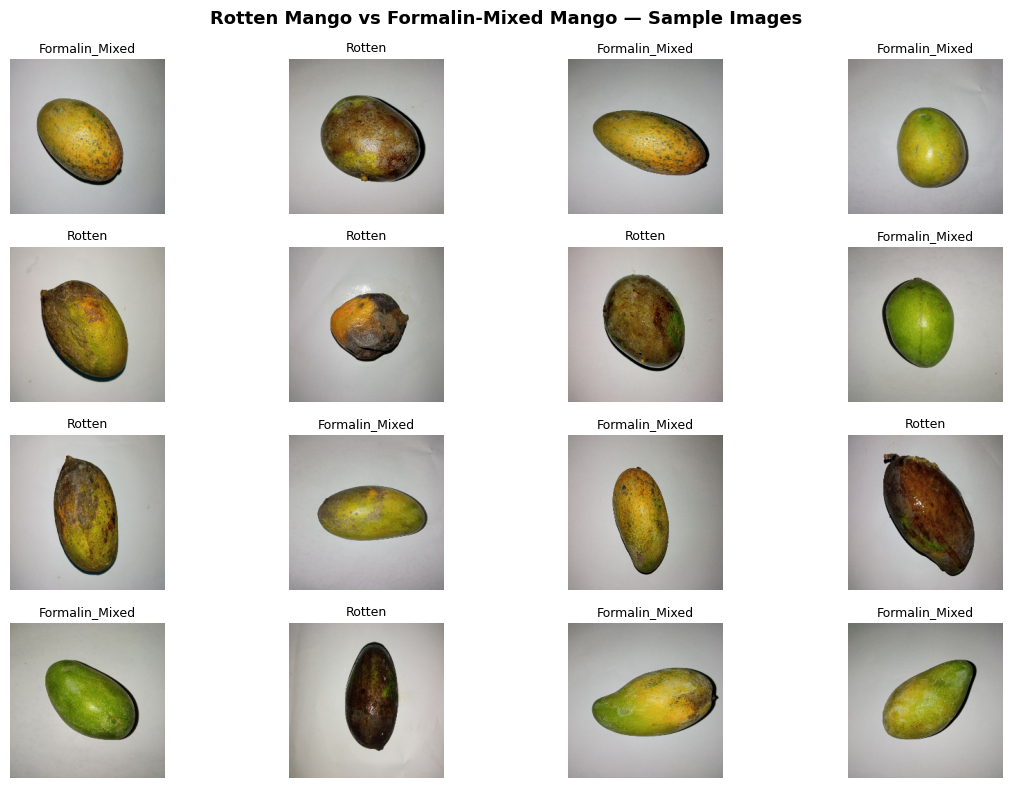

In [14]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')

plt.suptitle('Rotten Mango vs Formalin-Mixed Mango — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


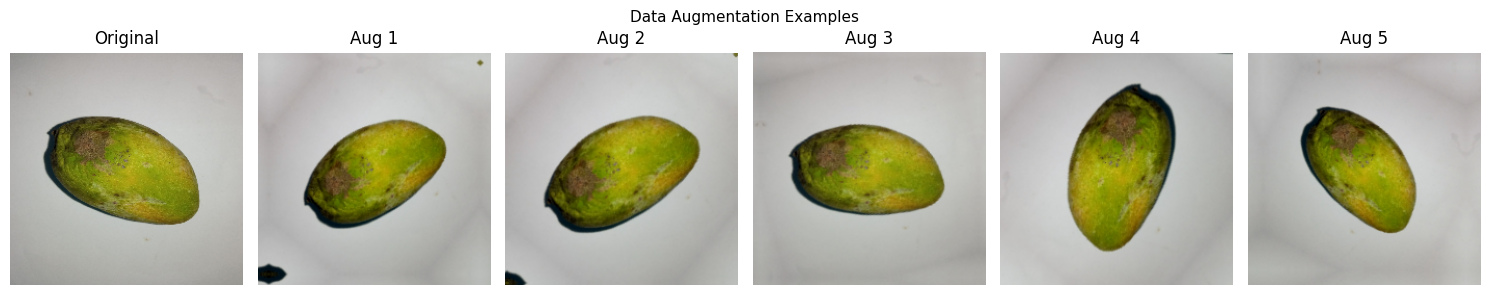

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name='data_augmentation')

for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 6):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
def make_callbacks(name, model_dir=MODEL_DIR):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(model_dir, f'{name}_best.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=3, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label='Train Accuracy',      linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label='Train Loss',      linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, class_names, title='Model'):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f'\n{title}')
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)


print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [18]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_transfer_model(input_shape, augmentation):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    inputs  = tf.keras.Input(shape=input_shape)
    x       = augmentation(inputs)
    x       = preprocess_fn(x)
    x       = base_model(x, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.Dense(128, activation='relu')(x)
    x       = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='mobilenetv2_mango'), base_model


tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model      : mobilenetv2_1.00_224
Trainable layers: 0 / 154


Model: "mobilenetv2_mango"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# Phase 1 — Feature Extraction (base frozen)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('mobilenetv2_mango_feature_extraction'),
    verbose=1,
)

Epoch 1/20
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6322 - loss: 0.6184
Epoch 1: val_accuracy improved from None to 0.80319, saving model to /content/drive/MyDrive/ME1/model/mobilenetv2_mango_feature_extraction_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME1/model/mobilenetv2_mango_feature_extraction_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 231ms/step - accuracy: 0.7420 - loss: 0.5091 - val_accuracy: 0.8032 - val_loss: 0.4566 - learning_rate: 1.0000e-04
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8622 - loss: 0.3367
Epoch 2: val_accuracy improved from 0.80319 to 0.81915, saving model to /content/drive/MyDrive/ME1/model/mobilenetv2_mango_feature_extraction_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ME1/model/mobilenetv2_mango_feature_extraction_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8911 - loss: 0.2923 - val_accuracy: 0.8191 - val_loss: 0.4001 - learning_rate: 1.0000e-04
Epoch

MobileNetV2 TL -> val_loss    : 0.2661
MobileNetV2 TL -> val_accuracy: 0.8511


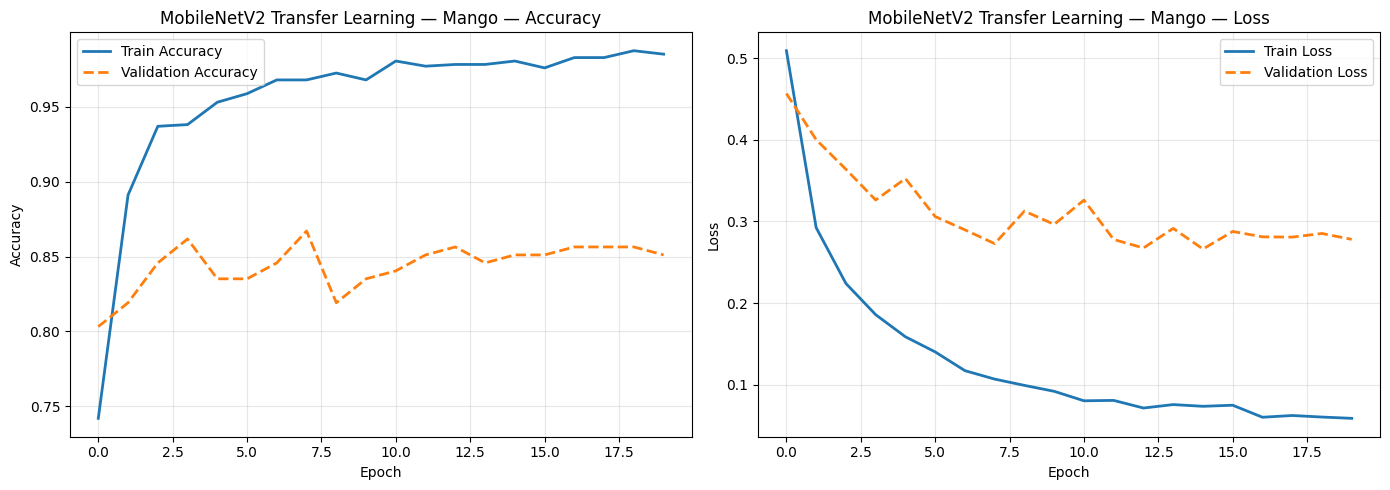

In [20]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV2 TL -> val_loss    : {tl_val_loss:.4f}')
print(f'MobileNetV2 TL -> val_accuracy: {tl_val_acc:.4f}')

plot_learning_curves(tl_history, 'MobileNetV2 Transfer Learning — Mango')


MobileNetV2 Transfer — Mango
Accuracy  : 0.8511
Precision : 0.7913
Recall    : 0.9579
F1-Score  : 0.8667

Classification Report:
                precision    recall  f1-score   support

Formalin_Mixed     0.9452    0.7419    0.8313        93
        Rotten     0.7913    0.9579    0.8667        95

      accuracy                         0.8511       188
     macro avg     0.8683    0.8499    0.8490       188
  weighted avg     0.8674    0.8511    0.8492       188



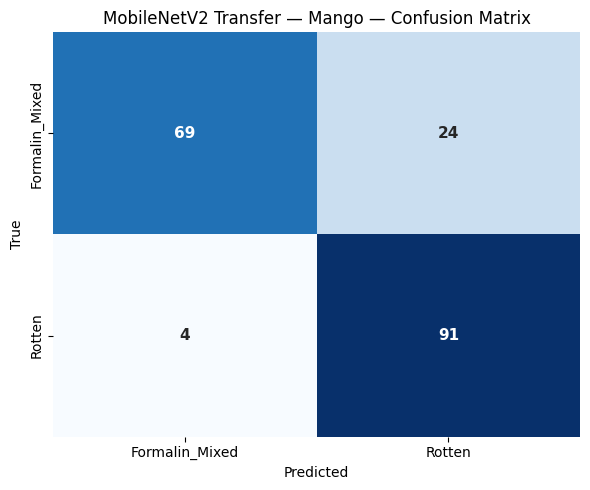

In [21]:
tl_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Transfer — Mango'
)

In [22]:
# Phase 2 — Fine-Tuning (unfreeze top 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Trainable base layers after unfreezing: 30 / 154


In [23]:
FINETUNE_LR = LR / 10   # 1e-5

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

In [24]:
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=make_callbacks('mobilenetv2_mango_finetuned'),
    verbose=1,
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9145 - loss: 0.2387
Epoch 1: val_accuracy improved from None to 0.92021, saving model to /content/drive/MyDrive/ME1/model/mobilenetv2_mango_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME1/model/mobilenetv2_mango_finetuned_best.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.9427 - loss: 0.1694 - val_accuracy: 0.9202 - val_loss: 0.2406 - learning_rate: 1.0000e-05
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9750 - loss: 0.0929
Epoch 2: val_accuracy did not improve from 0.92021
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.9759 - loss: 0.0933 - val_accuracy: 0.8777 - val_loss: 0.3482 - learning_rate: 1.0000e-05
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9896 - loss: 0.0598
Epoch 3: val_accuracy did not improve from 0.92021
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9839 - loss: 0.0660 - val_accuracy: 0.8457 - val_lo

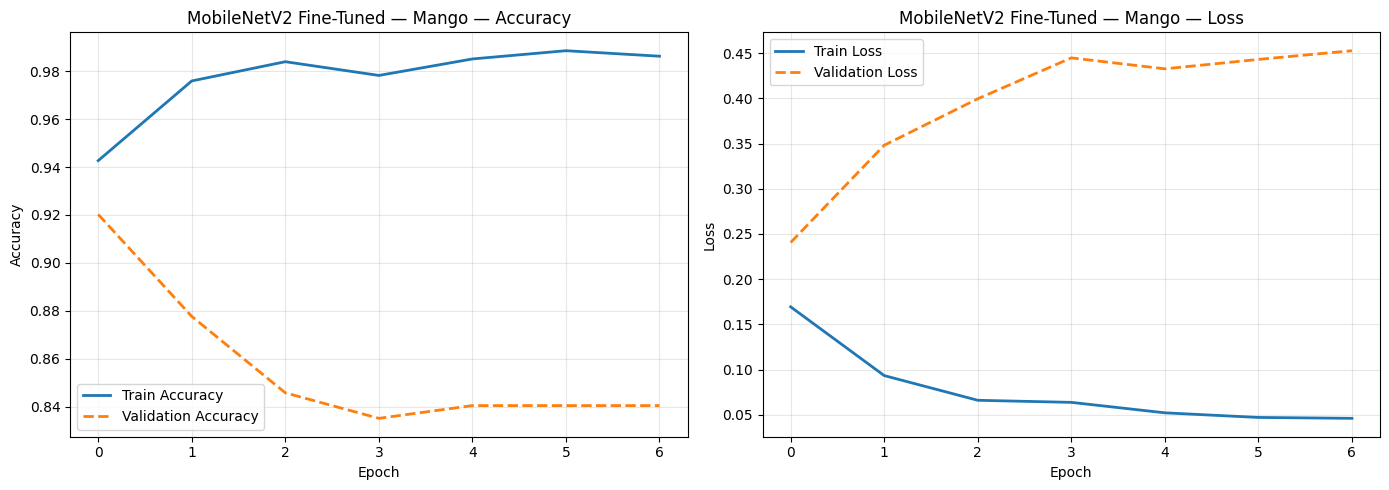


MobileNetV2 Fine-Tuned — Mango
Accuracy  : 0.9202
Precision : 0.9878
Recall    : 0.8526
F1-Score  : 0.9153

Classification Report:
                precision    recall  f1-score   support

Formalin_Mixed     0.8679    0.9892    0.9246        93
        Rotten     0.9878    0.8526    0.9153        95

      accuracy                         0.9202       188
     macro avg     0.9279    0.9209    0.9199       188
  weighted avg     0.9285    0.9202    0.9199       188



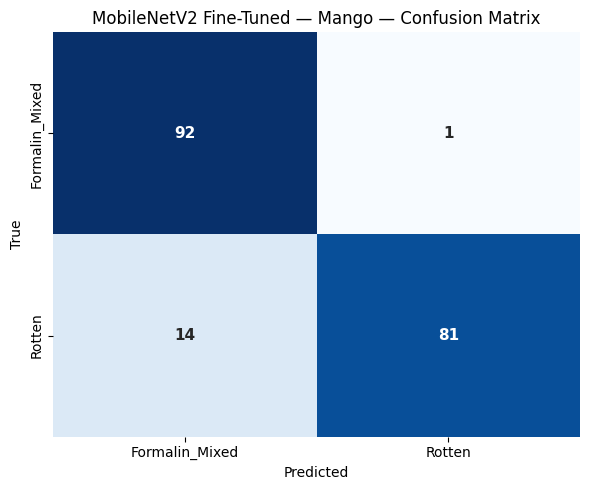


--- Summary ---
Feature-extraction test accuracy : 0.8511
Fine-tuned         test accuracy : 0.9202


In [25]:
plot_learning_curves(ft_history, 'MobileNetV2 Fine-Tuned — Mango')

ft_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Fine-Tuned — Mango'
)

print('\n--- Summary ---')
print(f'Feature-extraction test accuracy : {tl_test_acc:.4f}')
print(f'Fine-tuned         test accuracy : {ft_test_acc:.4f}')

In [26]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with the trained model."""
    img       = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    prob       = model.predict(img_array, verbose=0)[0][0]
    label      = class_names[int(prob >= 0.5)]
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'Prediction : {label}')
    print(f'Confidence : {confidence:.4f}')


print('predict_image() utility defined.')
print('Usage: predict_image("/path/to/mango.jpg", tl_model, class_names)')

predict_image() utility defined.
Usage: predict_image("/path/to/mango.jpg", tl_model, class_names)


In [27]:
FINAL_MODEL_PATH = '/content/drive/MyDrive/ME1/model/mango_rotten_formalin_model.keras'
tl_model.save(FINAL_MODEL_PATH)

print('Model saved:')
print(f'  {FINAL_MODEL_PATH}')
print(f'  Final test accuracy: {ft_test_acc:.4f}')

Model saved:
  /content/drive/MyDrive/ME1/model/mango_rotten_formalin_model.keras
  Final test accuracy: 0.9202


In [ ]:
# ── Generate class_stats.npz for OOD Layer 2 ─────────────────────────────────────────────
# Run this cell ONCE after training.
# We reload val images directly from disk (no augmentation pipeline) so the
# per-class feature statistics are clean and stable — matching what app.py
# sees at inference time.

import numpy as np
import keras

CLASS_STATS_PATH = FINAL_MODEL_PATH.replace(FINAL_MODEL_PATH.split('/')[-1], 'class_stats.npz')

# Load the saved model
saved_model = keras.models.load_model(FINAL_MODEL_PATH)
print('Model loaded from:', FINAL_MODEL_PATH)

# Build feature extractor: model.input → GlobalAveragePooling2D
gap_layer = next(
    l for l in reversed(saved_model.layers)
    if isinstance(l, keras.layers.GlobalAveragePooling2D)
)
feature_extractor = keras.Model(
    inputs=saved_model.input,
    outputs=gap_layer.output,
    name='feature_extractor',
)
print(f'Feature extractor output shape: {feature_extractor.output_shape}')

# Reload val set FRESH from disk (no cache, no augmentation)
# This ensures features match exactly what app.py computes at inference time.
val_dataset_clean = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

# Collect features and labels
all_features, all_labels = [], []
for imgs, lbls in val_dataset_clean:
    feats = feature_extractor(imgs, training=False).numpy()
    all_features.append(feats)
    all_labels.append(lbls.numpy().flatten())

all_features = np.concatenate(all_features, axis=0)  # (N, 1280)
all_labels   = np.concatenate(all_labels,   axis=0)  # (N,)
print(f'Collected {len(all_features)} val samples, feature dim={all_features.shape[1]}')

# Compute per-class mean and std
class_means, class_stds = [], []
for idx, name in enumerate(class_names):
    mask        = all_labels == idx
    class_feats = all_features[mask]
    class_means.append(class_feats.mean(axis=0))
    class_stds.append(class_feats.std(axis=0) + 1e-8)  # avoid div-by-zero
    print(f'  {name}: {mask.sum()} samples')

class_means = np.array(class_means)  # (n_classes, 1280)
class_stds  = np.array(class_stds)   # (n_classes, 1280)

# Save to Drive
np.savez(CLASS_STATS_PATH, means=class_means, stds=class_stds, class_names=class_names)
print(f'\nclass_stats.npz saved to: {CLASS_STATS_PATH}')
print('OOD Layer 2 is now enabled in the Streamlit app.')


Model loaded from: /content/drive/MyDrive/ME1/model/mango_rotten_formalin_model.keras
Feature extractor output shape: (None, 1280)
Collected 188 val samples, feature dim=1280
  Formalin_Mixed: 93 samples
  Rotten: 95 samples

class_stats.npz saved to: /content/drive/MyDrive/ME1/model/class_stats.npz
OOD Layer 2 is now enabled in the Streamlit app.
